# Battery SoH prediction

*Author*: Nicole Segura Salas

Date created: 20/05/2026

Description: This notebook shows the exploratory data analysis on battery aging tests. 

## Forecasting battery degradation based on it's State of Health

The data set can be found in the following repository [link](https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip).

SOH: State of health estimation is a relative variable that compares the current state of the battery with its initial condition: 
$$
SOH = \frac{\text{Current actual capacity (Ah)}}{\text{Nominal Capacity (Ah)}} x 100
$$

The EoL (end of life) of the battery is defined as when the capacity is lower than the acceptable performance threshold (APT) usually given by the manufacturer and conventionally set to ~70% of the rated capacity. 

Battery aging can be defined based on: 
(i) calendar aging : Associated to the consequences of battery storage. 
(ii) cycle aging: Associated with impact of the battery utilization periods. 

This defined the problem for time series forecasting.

Main problem: There is not a single parameter that can determine the exact SOH of a battery, but rather a complex network of related aspects. 

Main question: Can the SOH of a battery be predicted? 

### Relevant libraries for this notebook

In [1]:
#importing libraries
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import importlib
import utils


## Important functions

In [191]:
importlib.reload(utils)
from utils import time_format,preprocessing_meta,battery_cycles_df,continuous_time,current_capacity,visualization_2by2, timeTmax, time_Tmax3,area_under_curve, time_to_voltage, charging_decay, charging_slope, ransac_clean_outliers, discharge_Tmax, time_discharge

## Goal of the exploratory analysis

The data offers charge and discharge cycles, as well as impedance analysis for several batteries under several conditions. 

1. One aspect of SOH: The capacity would change over charge-discharge cycle numbers. More likely, it will decrease.
2. Impedance: would also change over charge-discharge cycles, more likely it will grow.

- These datasets can be used for the prediction of both remaining charge (for a given discharge cycle) and remaining useful life (RUL).

Find relevant physical parameters as battery health descriptors


## Data Loading

In [192]:
#Metadata
meta = pd.read_csv("metadata.csv")

#Cleaning the format from symbols
meta = time_format(meta)

#Converting relevant data to numeric 
meta = preprocessing_meta(meta)

#Selecting the working battery group: 
B_batch1 = ["B0005","B0006","B0007","B0018"]

meta_batch1 = meta.iloc[meta["battery_id"].isin(B_batch1)].reset_index(drop=True)
meta_batch1.head()


,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,new_time
0,charge,24,B0006,0,4505,04505.csv,NaN,NaN,NaN,2008-04-02 13:08:17.920999
1,discharge,24,B0006,1,4506,04506.csv,2.035338,NaN,NaN,2008-04-02 15:25:41.593000
2,charge,24,B0006,2,4507,04507.csv,NaN,NaN,NaN,2008-04-02 16:37:51.984000
3,discharge,24,B0006,3,4508,04508.csv,2.025140,NaN,NaN,2008-04-02 19:43:48.405999
4,charge,24,B0006,4,4509,04509.csv,NaN,NaN,NaN,2008-04-02 20:55:40.811999


In [193]:
meta_batch1.isna().sum() 
#NaN values are accepted for capacity, electrolyte resistance (Re) and charge transfer resistance (Rct)

type                      0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               1531
Re                     1280
Rct                    1280
new_time                  0
dtype: int64

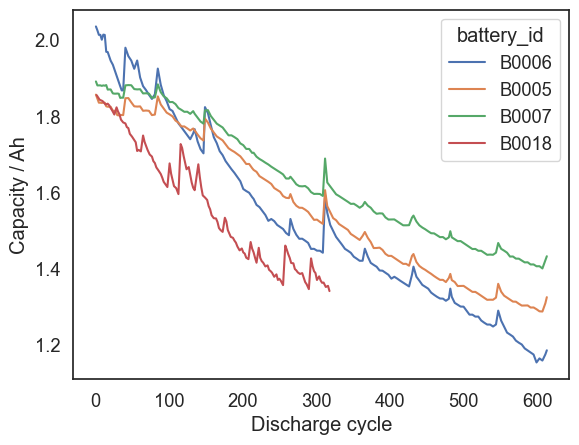

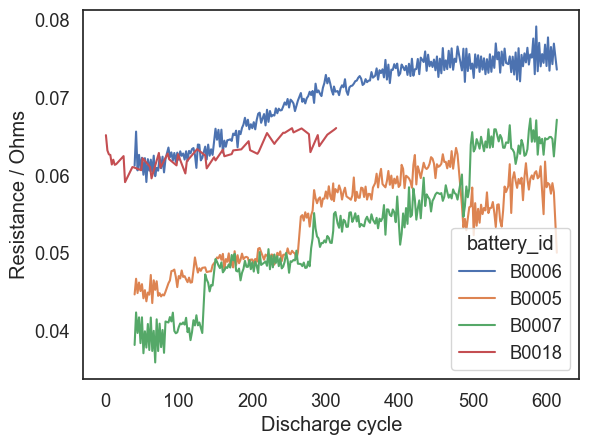

In [194]:
#Plotting the initial capacity given in metadata
sns.set_theme(font_scale=1.2, style="white")
sns.lineplot(meta_batch1, x="test_id", y="Capacity", hue="battery_id")
plt.xlabel("Discharge cycle")
plt.ylabel("Capacity / Ah")
plt.show()
sns.lineplot(meta_batch1, x="test_id", y="Re", hue="battery_id")
#sns.lineplot(meta_batch1, x="test_id", y="Rct", hue="battery_id")
plt.xlabel("Discharge cycle")
plt.ylabel("Resistance / Ohms")
plt.show()

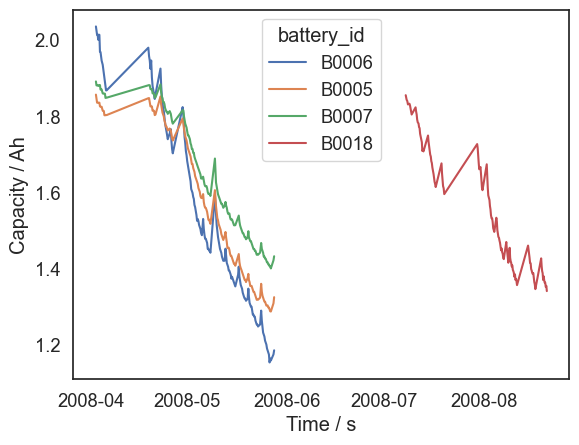

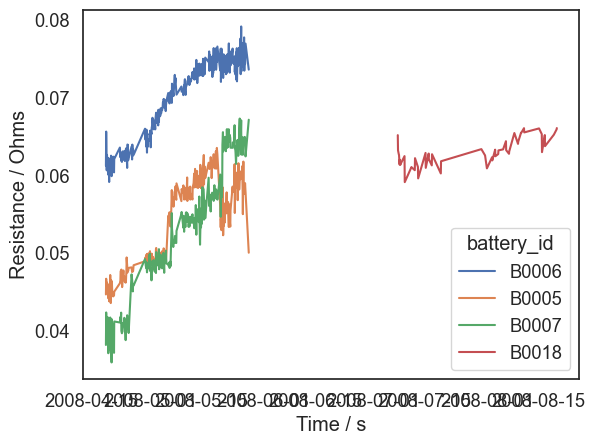

In [195]:
sns.lineplot(meta_batch1, x="new_time", y="Capacity", hue="battery_id")
plt.xlabel("Time / s")
plt.ylabel("Capacity / Ah")
plt.show()
sns.lineplot(meta_batch1, x="new_time", y="Re", hue="battery_id")
#sns.lineplot(meta_batch1, x="test_id", y="Rct", hue="battery_id")
plt.xlabel("Time / s")
plt.ylabel("Resistance / Ohms")
plt.show()

## Observations: 
The data follows the expected tendency where capacity decreases as resistance increases. But the times of each test seem to be not such a good parameter for comparison, at the beginning stage. The tests show inconsistencies which might be due to experimental conditions, or maybe the tests where rescheduled. 

## Loading degradation dataset

In [196]:
#Selecting batteries from metadata
B1_charge_discharge = battery_cycles_df(meta, B_batch1, ["discharge","charge"])
#Time is normalized
B1_charge_discharge = continuous_time(B1_charge_discharge)
#Capacity is calculated based on the integral of the current charge plot
B1_charge_discharge = current_capacity(B1_charge_discharge)

In [197]:
B1_charge_discharge.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,new_time,Capacity,Current_load,Voltage_load,dt_exp,real_time,norm_time,capacity_Ah
0,3.873017,-0.001201,24.655358,0.000,0.003,0.000,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,0.0,0.000,0.000000e+00,0.000000
1,3.479394,-4.030268,24.666480,-4.036,1.570,2.532,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,0.0,2.532,5.240829e-07,-0.002835
2,4.000588,1.512731,24.675394,1.500,4.726,5.500,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,0.0,5.500,1.138411e-06,-0.001587
3,4.012395,1.509063,24.693865,1.500,4.742,8.344,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,0.0,8.344,1.727073e-06,-0.000395
4,4.019708,1.511318,24.705069,1.500,4.753,11.125,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,0.0,11.125,2.302694e-06,0.000772


# EDA

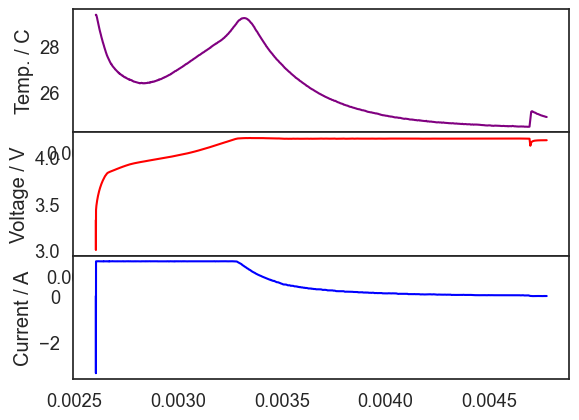

In [200]:
#Plotting the Change of capacity during cycles
from matplotlib import gridspec
fig=plt.figure()
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 3]) 
# the first subplot
mask = ((B1_charge_discharge["battery_id"]=="B0005")&(B1_charge_discharge["test_id"]==2))
x=B1_charge_discharge.loc[mask].iloc[:5000]["norm_time"]
y1=B1_charge_discharge.loc[mask].iloc[:5000]["Temperature_measured"]
y2=B1_charge_discharge.loc[mask].iloc[:5000]["Voltage_measured"]
y3=B1_charge_discharge.loc[mask].iloc[:5000]["Current_measured"]

ax0 = plt.subplot(gs[0])
line0, = ax0.plot(x,y1, color="purple")

ax1 = plt.subplot(gs[1], sharex = ax0)
line1, = ax1.plot(x, y2, color='red')

ax2 = plt.subplot(gs[2], sharex = ax0)
line1, = ax2.plot(x, y3, color='blue')

#ax0.legend((line0, line1), ('Voltage', 'Current','Temperature'), loc='upper left')

plt.subplots_adjust(hspace=.0)
ax0.set_ylabel("Temp. / C")

ax1.set_ylabel("Voltage / V")

ax2.set_ylabel("Current / A")

ax1.set_xlabel("Time / s")

plt.show()

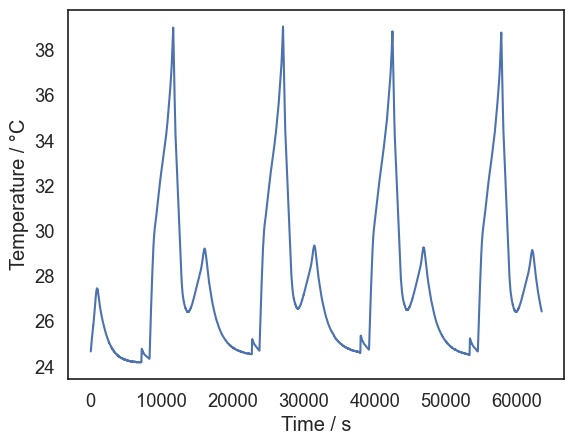

In [202]:
x=B1_charge_discharge.loc[B1_charge_discharge["battery_id"]=="B0005"].iloc[:5000]["real_time"]
y3=B1_charge_discharge.loc[B1_charge_discharge["battery_id"]=="B0005"].iloc[:5000]["Temperature_measured"]
plt.plot(x,y3)
plt.xlabel("Time / s")
plt.ylabel("Temperature / °C")
plt.show()

# Data Visualization

## Charging

In [ ]:
B1_charge = battery_cycles_df(meta, B_batch1, "charge")
B1_charge = continuous_time(B1_charge)
B1_charge = current_capacity(B1_charge)
B1_charge.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,new_time,dt_time,real_time,norm_time,capacity_Ah
0,3.873017,-0.001201,24.655358,0.000,0.003,0.000,charge,0,B0005,2008-04-02 13:08:17.920999,0.0,0.0,0.0,0.000000
1,3.479394,-4.030268,24.666480,-4.036,1.570,2.532,charge,0,B0005,2008-04-02 13:08:17.920999,0.0,0.0,0.0,-0.002835
2,4.000588,1.512731,24.675394,1.500,4.726,5.500,charge,0,B0005,2008-04-02 13:08:17.920999,0.0,0.0,0.0,-0.001587
3,4.012395,1.509063,24.693865,1.500,4.742,8.344,charge,0,B0005,2008-04-02 13:08:17.920999,0.0,0.0,0.0,-0.000395
4,4.019708,1.511318,24.705069,1.500,4.753,11.125,charge,0,B0005,2008-04-02 13:08:17.920999,0.0,0.0,0.0,0.000772


Text(0, 0.5, 'Current / A')

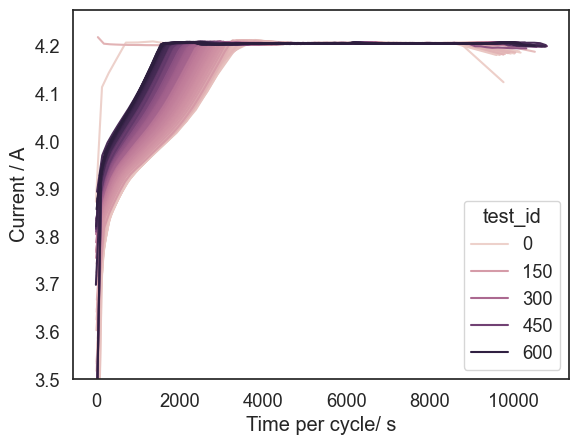

In [208]:
dfc = B1_charge[["Voltage_measured","Current_measured","Temperature_measured","Time","battery_id","test_id"]].loc[(B1_charge["battery_id"]=="B0005")].iloc[::50]
sns.set_theme(font_scale=1.2, style="white")
sns.lineplot(data=dfc, x="Time", y="Voltage_measured", hue="test_id")
plt.ylim(3.5)
plt.xlabel("Time per cycle/ s")
plt.ylabel("Current / A")

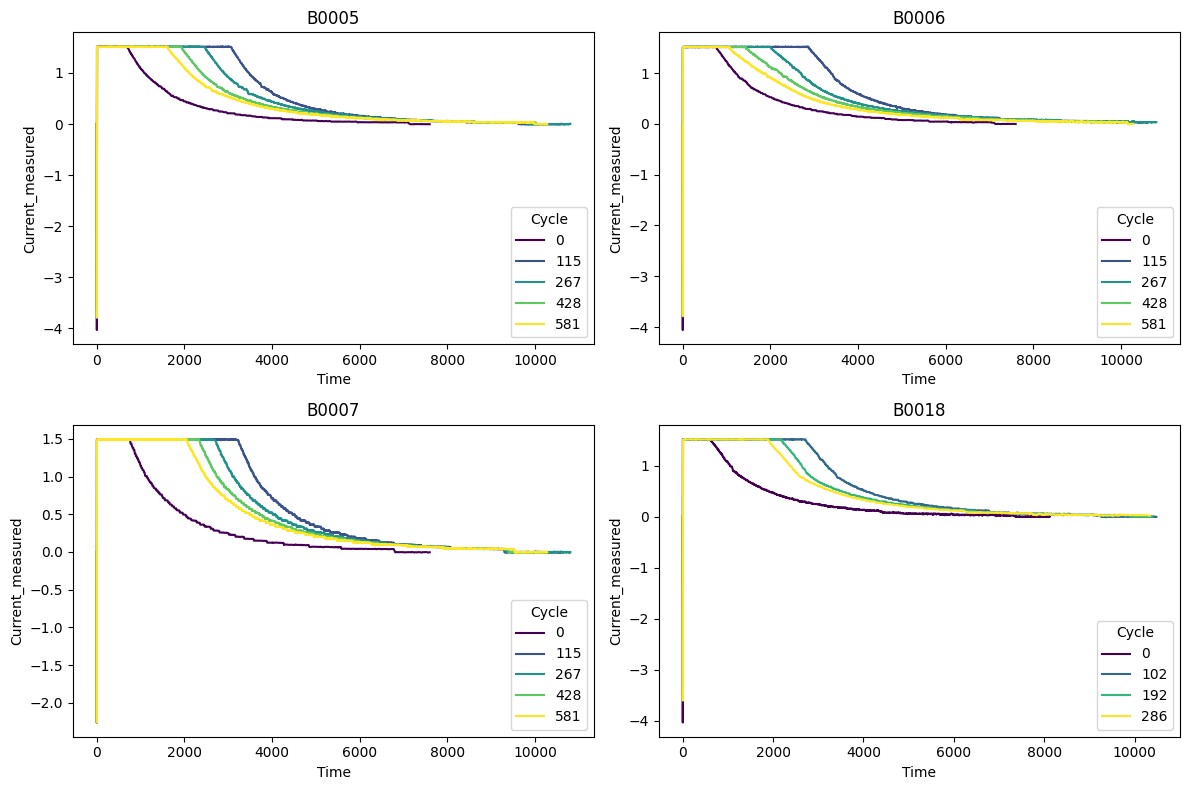

In [15]:
visualization_2by2(B1_charge, "Time", "Current_measured")
plt.tight_layout()
plt.show()

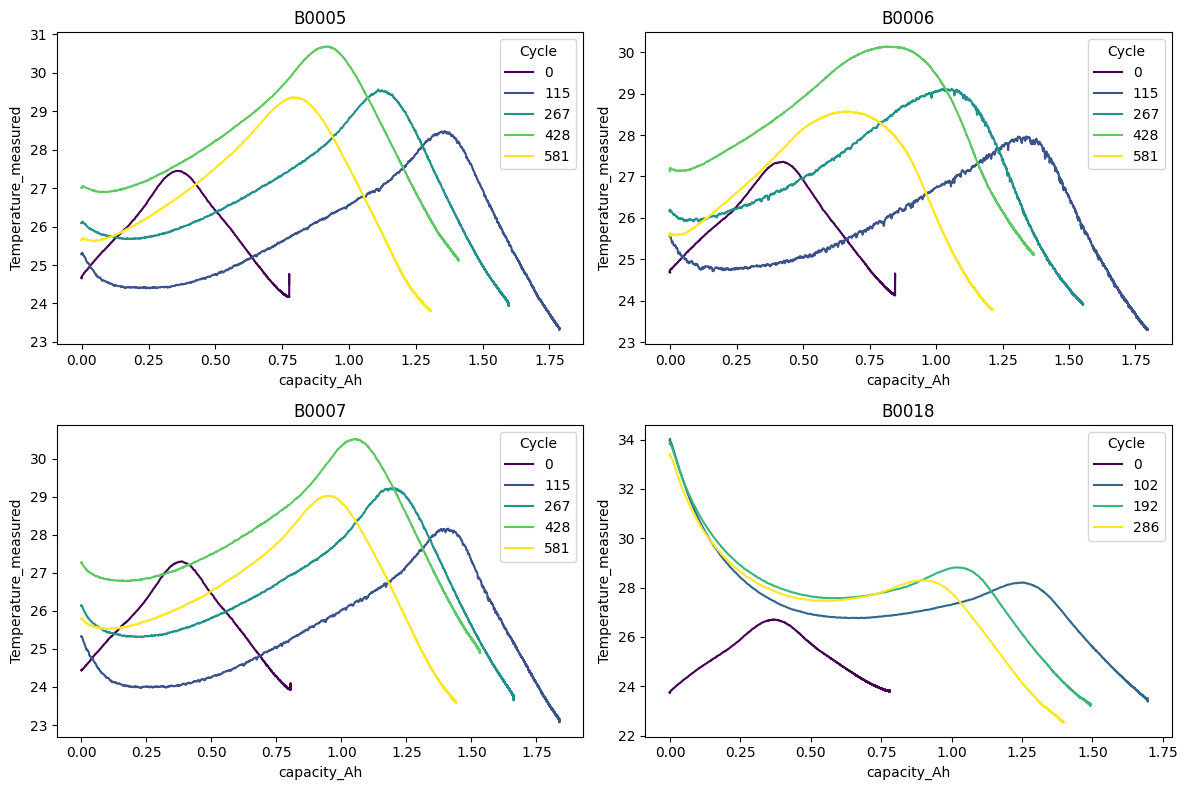

In [21]:
visualization_2by2(B1_charge, "capacity_Ah", "Temperature_measured")
plt.tight_layout()
plt.show()

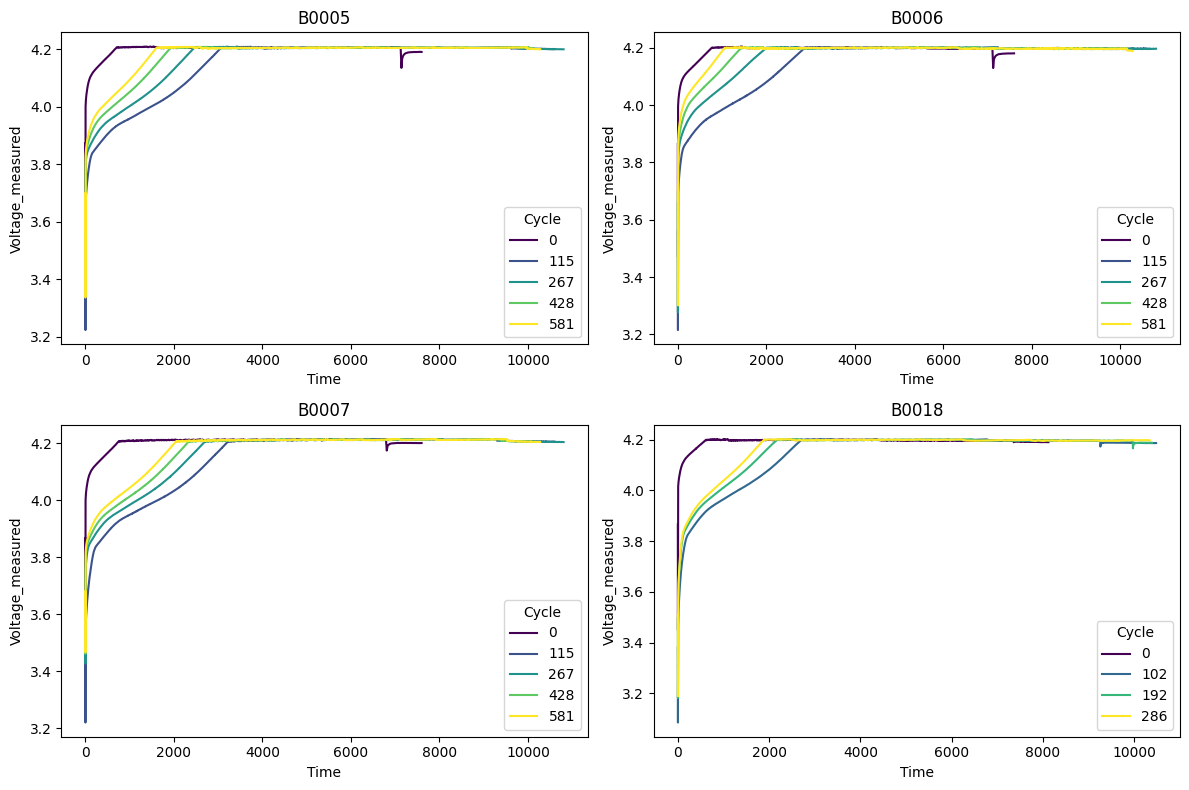

In [17]:
visualization_2by2(B1_charge, "Time", "Voltage_measured")
plt.tight_layout()
plt.show()

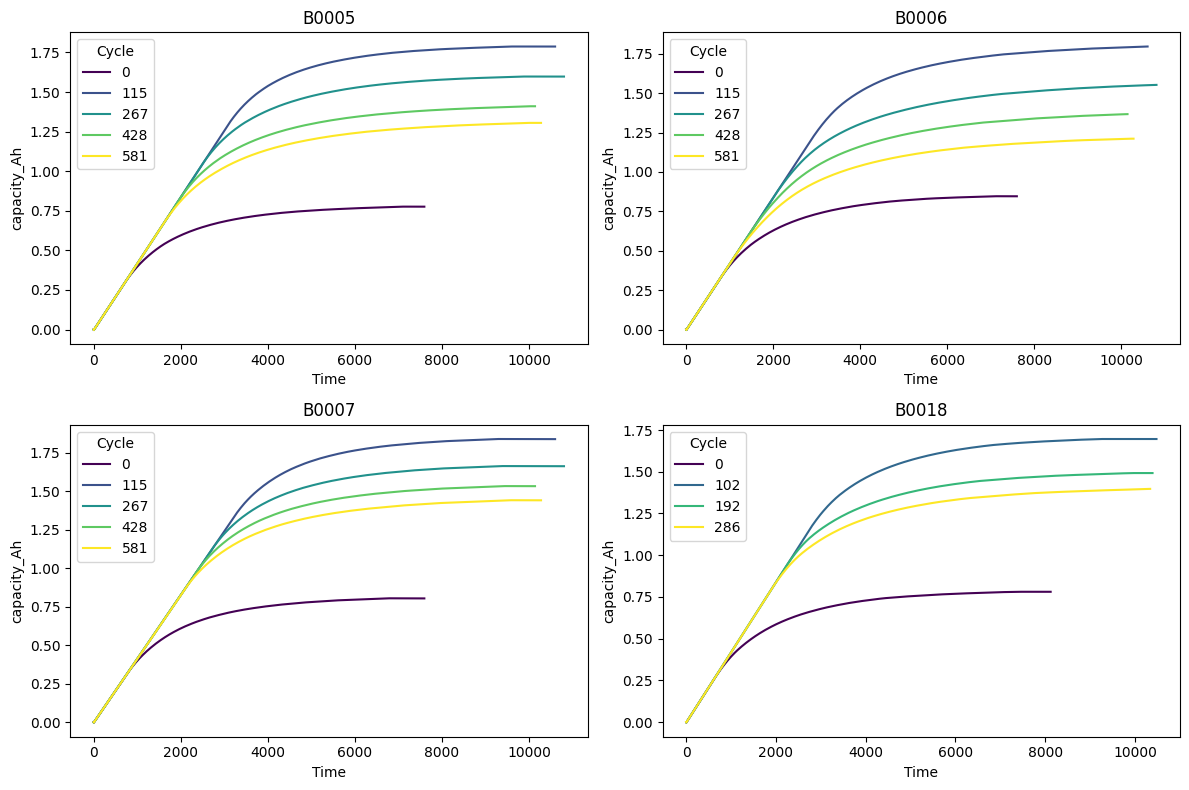

In [19]:
visualization_2by2(B1_charge, "Time", "capacity_Ah")
plt.tight_layout()
plt.show()

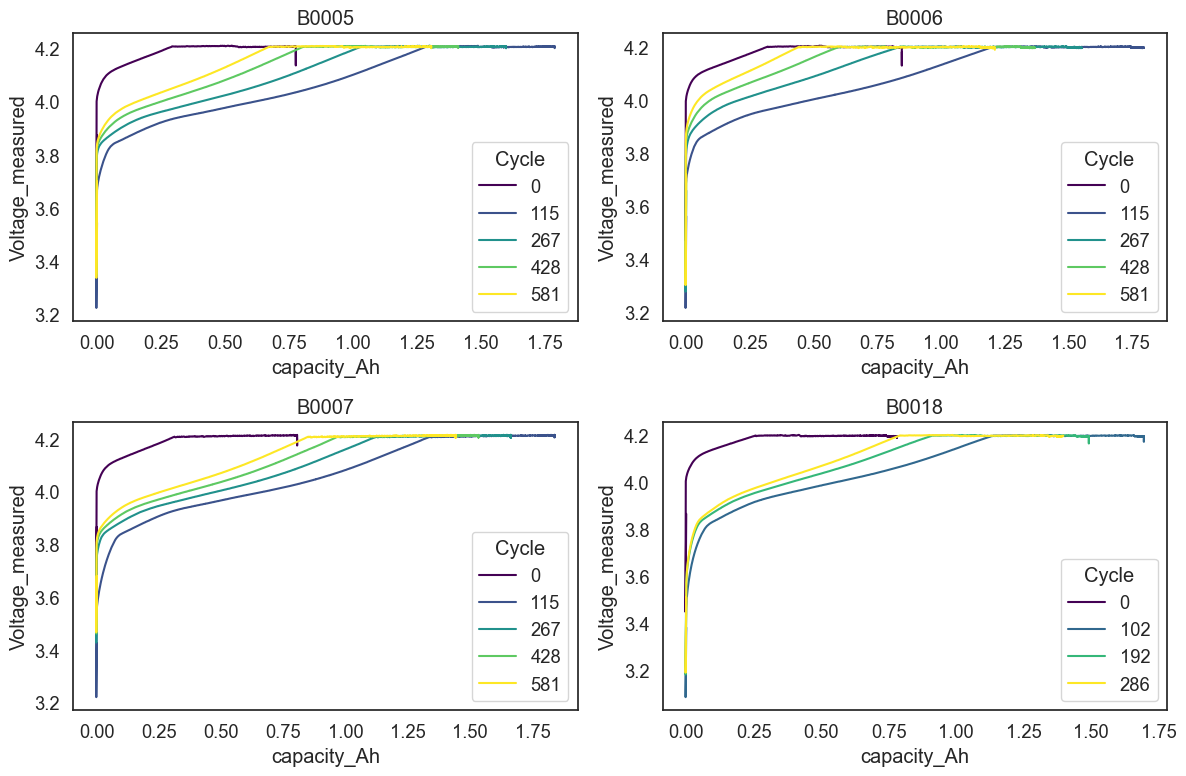

In [183]:
visualization_2by2(B1_charge, "capacity_Ah","Voltage_measured")
plt.tight_layout()
plt.show()

## Main observations from battery charging cycles

1. Cycle 0 is not representative for the following behavior of the battery as it has not yet been stabilized. 
2. the increase of temperature during charging is associated to the time it takes to reach 4.2 V and finish the constant current phase. 
3. With increasing cycles, the battery behavior changes to what would be the opposite of aging, and might be due to reconfiguration of the anode and cathode structures after cycling. One may have to analyze the impedance spectra. 

## actions: 
1. Calculate the time it takes to get to 4.2 V for each cycle. 
2. Time of maximum temperature vs time of 4.2 V to charge. 
3. Fit exponentially the curve of discharge to compare evolution of charging efficiency. 

## Max Temperature

### Peak detection

In [22]:
#Find a way to smooth the Temperature signal 
#B0006 sample 115
smooth_test = B1_charge[["Temperature_measured","Time"]].loc[((B1_charge["battery_id"]=="B0018")&(B1_charge["test_id"]==192))].reset_index(drop=True)

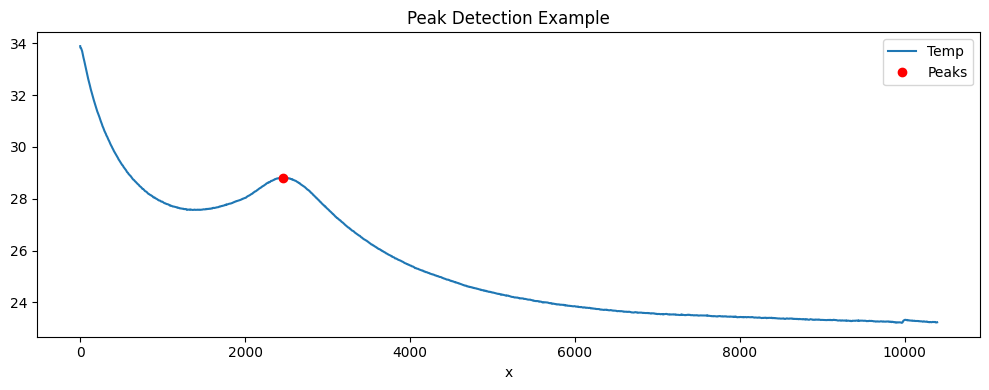

In [23]:
from scipy.signal import find_peaks
# Detect peaks
peaks, properties = find_peaks(smooth_test["Temperature_measured"],prominence=1, height = [5,35])
# Plot the results
plt.figure(figsize=(10,4))
plt.plot(smooth_test["Time"], smooth_test["Temperature_measured"], label='Temp')
plt.plot(smooth_test["Time"][peaks], smooth_test["Temperature_measured"][peaks], 'ro', label='Peaks')
plt.legend()
plt.xlabel('x')
plt.title('Peak Detection Example')
plt.tight_layout()
plt.show()

In [48]:
print(properties)

{'peak_heights': array([28.81932209]), 'prominences': array([1.25658875]), 'left_bases': array([256]), 'right_bases': array([1776])}


In [24]:
print(smooth_test["Time"][peaks])
print(smooth_test["Temperature_measured"][peaks])

460    2460.75
Name: Time, dtype: float64
460    28.819322
Name: Temperature_measured, dtype: float64


### Baseline with pybaseline

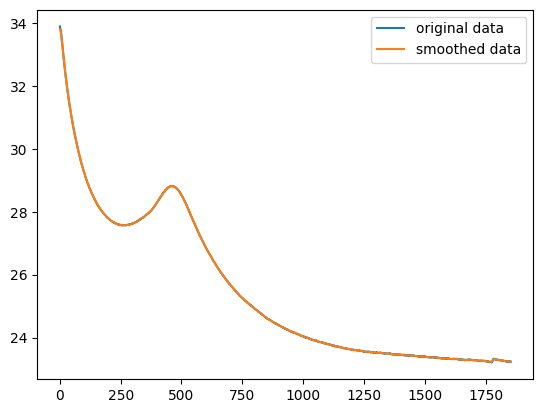

In [25]:
## We need to remove baseline, temperature in discharge can increase up to 40
from scipy.ndimage import uniform_filter1d
from pybaselines import Baseline
from pybaselines.utils import gaussian

smooth_y = uniform_filter1d(smooth_test["Temperature_measured"], 11)

plt.figure()
plt.plot(smooth_test["Temperature_measured"], label='original data')
plt.plot(smooth_y, label='smoothed data')
plt.legend()
        


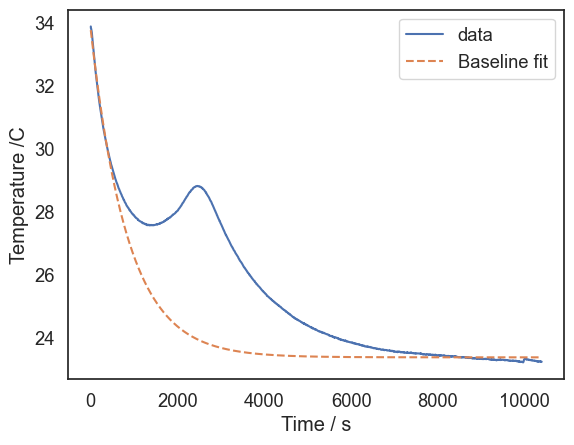

In [206]:

y = smooth_test["Temperature_measured"]
x=smooth_test["Time"]
baseline_fitter = Baseline(x_data=x)
flexible_baseline = baseline_fitter.arpls(y, lam=5e5)[0]
smoothed_imodpoly = baseline_fitter.imodpoly(y, poly_order=6, num_std=0.002)[0]
mixed = baseline_fitter.mixture_model(y, lam=1e3, p=0.5)[0]
isqr = baseline_fitter.irsqr(y, lam=5e5)[0]

crossover_index = np.argmin(abs(x -400))
lam_flexible = 1e2
fit_baseline, params = baseline_fitter.custom_bc(
    y, 'arpls',
    regions=([crossover_index, None],),
    sampling=15,
    method_kwargs={'lam': lam_flexible},
    lam=1e1
)

from scipy.optimize import curve_fit
import numpy as np
def exp_decay(x, A, k, c):

    return A * np.exp(-k * x) + c
mask = (
    (x < 500) |
    (x > 7000)
)
params, _ = curve_fit(
    exp_decay,
    x[mask],
    y[mask],
    p0=[10, 9e-2, 30]
)

baseline_exp = exp_decay(x, *params)

plt.figure()
plt.plot(x, y,label ='data')
#plt.plot(x, fit_baseline, label='Fit baseline')
#plt.plot(x,flexible_baseline, label='lam')
#plt.plot(x,smoothed_imodpoly, '--', label='smoothed modpoly')
#plt.plot(x,isqr, '--', label='isqr')
#plt.plot(x,mixed, '--', label='mixed')
plt.plot(x,baseline_exp, '--', label='Baseline fit')
plt.xlabel("Time / s")
plt.ylabel("Temperature /C")
plt.legend()

In [31]:
from pybaselines import Baseline
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

results_Tmax = []

grouped = B1_charge.groupby(["battery_id", "test_id"])

for (battery, cycle), cycle_df in grouped:

    cycle_df = cycle_df.sort_values("Time")
    cycle_df["Temp_smooth"] = gaussian_filter1d(cycle_df["Temperature_measured"],sigma=10)
    temp = cycle_df["Temp_smooth"].values

    time = cycle_df["Time"].values

    # Skip tiny cycles
    if len(time) < 20:
        continue

    def exp_decay(x, A, k, c):
        return A * np.exp(-k * x) + c
    
    c0= cycle_df["Temperature_measured"].iloc[-1]
    A0 = cycle_df["Temperature_measured"].iloc[0]-c0
    duration = cycle_df["Time"].max()
    k0 = 1/ duration

    p0 = (A0, k0, c0)

    mask = ((time < 500) | (time > 7000))
    params, _ = curve_fit(
        exp_decay,
        time[mask],
        temp[mask],
        p0=p0,
        maxfev=10000)

    baseline_exp = exp_decay(time, *params)

    y = temp - baseline_exp

    peaks, properties = find_peaks(y,prominence=1)

    if (len(peaks) == 0 or len(properties["prominences"]) == 0):

        print(f"No valid peak for "f"{battery}, cycle {cycle}")

        t_peak = np.nan
        T_peak = np.nan

    else:

        main_peak = peaks[np.argmax(properties["prominences"])]

        t_peak = time[main_peak]

        T_peak = y[main_peak]


        results_Tmax.append({
            "battery_id": battery,
            "test_id": cycle,
            "time_Tmax": t_peak,
            "T_peak": T_peak})



No valid peak for B0005, cycle 84
No valid peak for B0006, cycle 84
No valid peak for B0007, cycle 84
No valid peak for B0018, cycle 115
No valid peak for B0018, cycle 139


<Axes: xlabel='test_id', ylabel='time_Tmax'>

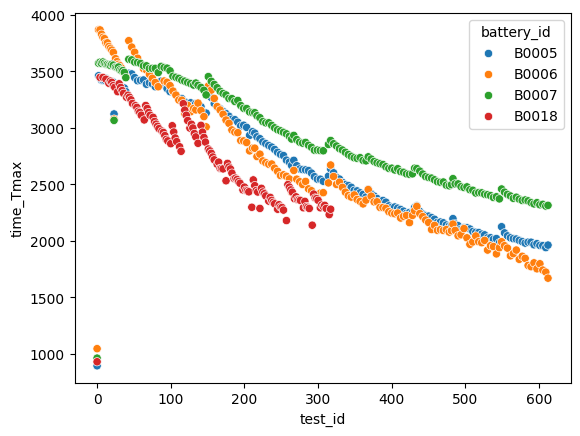

In [32]:
results_Tmax_df = pd.DataFrame(results_Tmax)
sns.scatterplot(data=results_Tmax_df, x="test_id", y="time_Tmax", hue="battery_id")

<Axes: xlabel='test_id', ylabel='T_peak'>

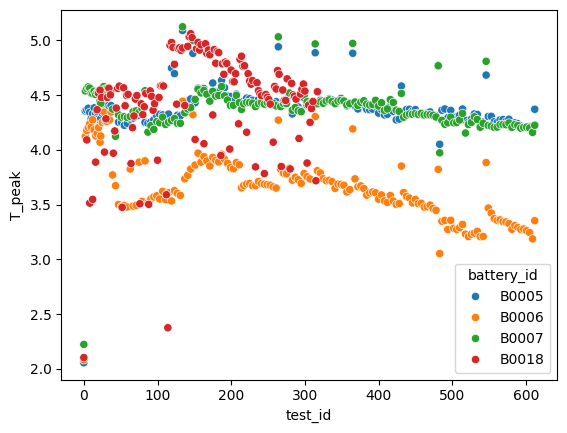

In [33]:
sns.scatterplot(data=results_Tmax_df, x="test_id", y="T_peak", hue="battery_id")

### Just by max value

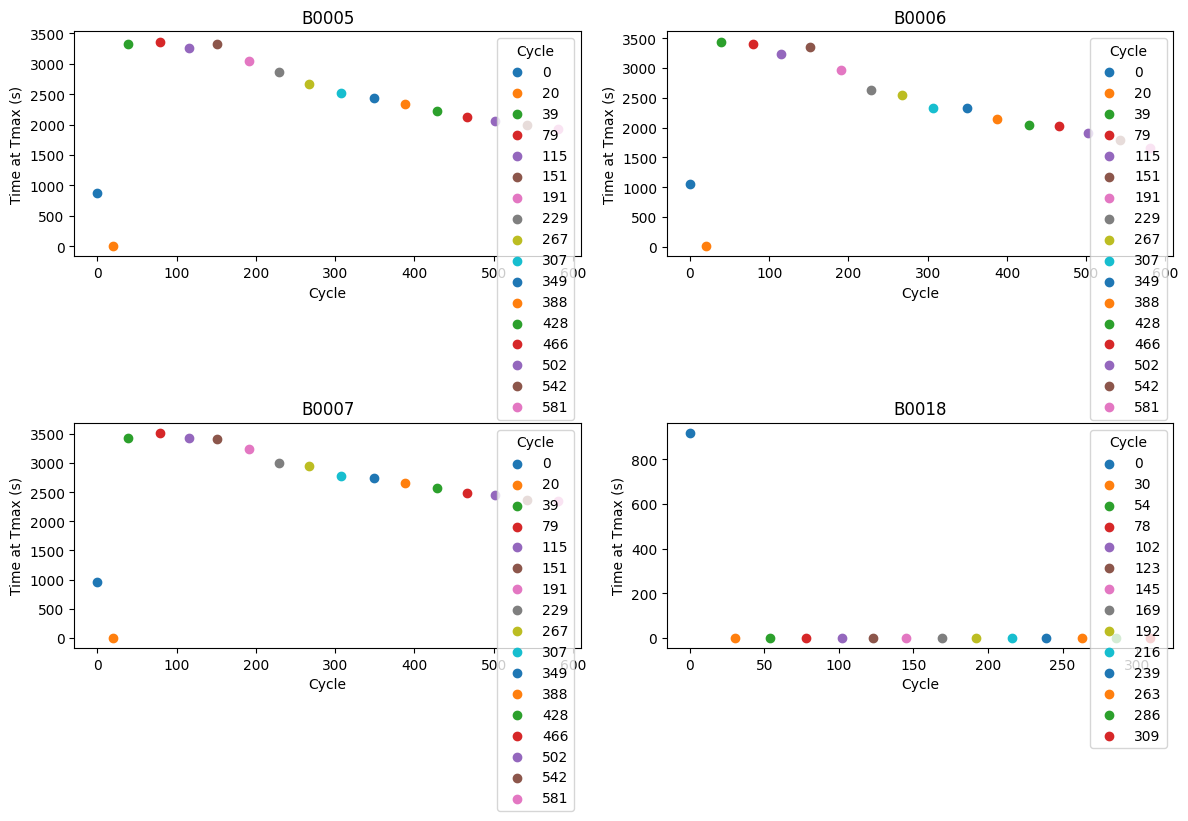

In [34]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

ax = ax.flatten()

batteries = B1_charge["battery_id"].unique()

for index, battery in enumerate(batteries):

    battery_df = B1_charge[B1_charge["battery_id"] == battery]

    cycles = battery_df["test_id"].unique()[::10]

    for cycle in cycles:

        cycle_df = battery_df[battery_df["test_id"] == cycle]

        # index label of Tmax
        idx_Tmax = cycle_df["Temperature_measured"].idxmax()

        # time where Tmax occurs
        time_Tmax = cycle_df.loc[idx_Tmax, "Time"]

        ax[index].scatter(cycle,time_Tmax,label=f"{cycle}")

    ax[index].set_title(battery)

    ax[index].set_xlabel("Cycle")
    ax[index].set_ylabel("Time at Tmax (s)")

    ax[index].legend(title="Cycle")


plt.tight_layout()
plt.show()

## Conclusion: 
The T_peak is not as relevant as the time when it reaches the max tem

### Area under T curve

(200000.0, 300000.0)

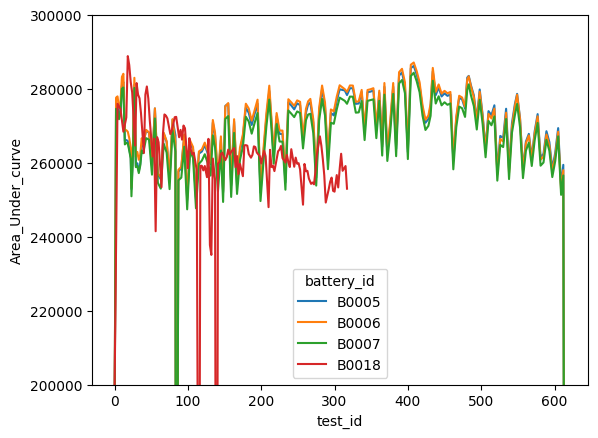

In [35]:
T_area = area_under_curve(df=B1_charge, x= "Time",y="Temperature_measured")
sns.lineplot(data=T_area, x=T_area["test_id"],y=T_area["Area_Under_curve"], hue="battery_id")
plt.ylim(200000,300000)

# Conclusion: 
Does not show significant trend

## Voltage

In [38]:
#define a time to voltage
def time_to_voltage(df, voltage_target = 4.2, tolerance = 0.05):
    import pandas as pd
    results = []
    grouped = df.groupby(["battery_id", "test_id"])
    for (battery, cycle), cycle_df in grouped:

        cycle_df = cycle_df.sort_values("Time")
        voltage = cycle_df["Voltage_measured"]
        mask = (np.abs(voltage-voltage_target))<=tolerance

        #required to sustain the value
        window=3
        rolling_hits = (mask.rolling(window).sum())
        idx = rolling_hits[rolling_hits==window].index
        
        if len(idx) ==0:
            t_reach= np.nan
        else: 
            first_idx = idx[0]
            t_reach=cycle_df.loc[first_idx,"Time"]
        results.append({
            "battery_id": battery,
            "test_id": cycle,
            "time_to_4p2V": t_reach
        })
    return pd.DataFrame(results)



<Axes: xlabel='test_id', ylabel='time_to_4p2V'>

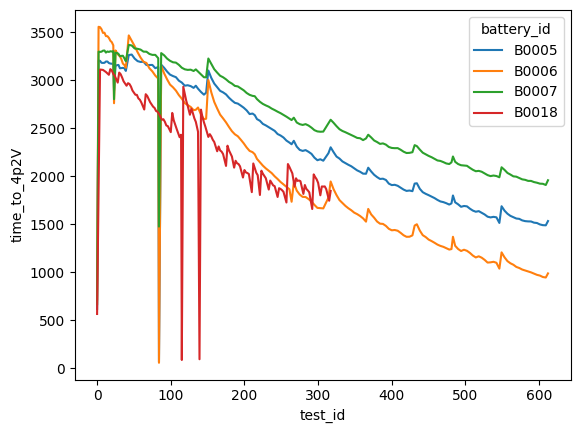

In [39]:
Time_to_42V = time_to_voltage(B1_charge, 4.2, 0.01)
sns.lineplot(data=Time_to_42V, x= Time_to_42V["test_id"], y=Time_to_42V["time_to_4p2V"], hue="battery_id")

<Axes: xlabel='test_id', ylabel='exp_coefficient'>

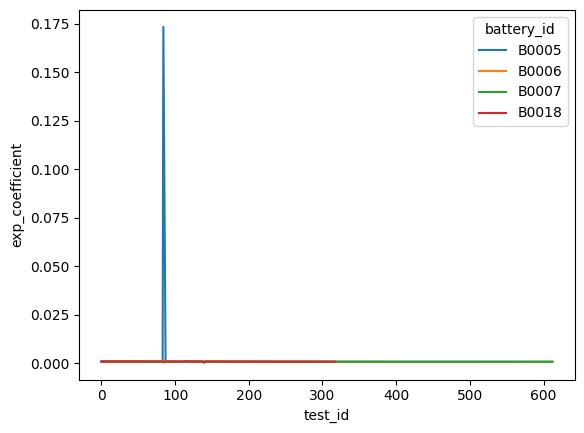

In [40]:
Charge_decay = charging_decay(B1_charge)
sns.lineplot(data=Charge_decay, x= Charge_decay["test_id"], y=Charge_decay["exp_coefficient"], hue="battery_id")

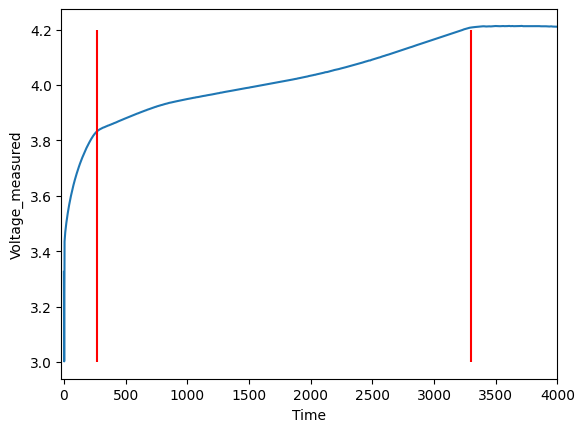

In [41]:
sns.lineplot(data=B1_charge.loc[((B1_charge["battery_id"]=="B0005")&(B1_charge["test_id"]==2))], x="Time", y="Voltage_measured")
plt.xlim(-20,4000)
plt.vlines(x=270, ymin=3, ymax=4.2, color="red")
plt.vlines(x=3300, ymin=3, ymax=4.2,color="red")

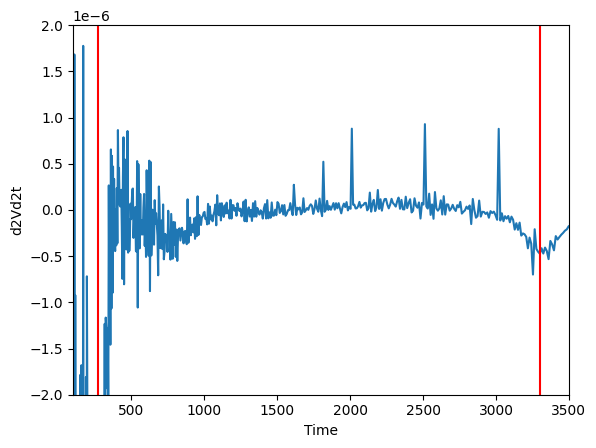

In [42]:
## Select the dataframe with values that represent the slope 
#where the change od voltage ot capacity is positive 
from scipy.ndimage import gaussian_filter1d

B1_charge["V_smooth"] = gaussian_filter1d(B1_charge["Voltage_measured"],sigma=10)

B1_charge["dVdt"] = B1_charge["V_smooth"].diff()/B1_charge["Time"].diff()
B1_charge["d2Vd2t"] = B1_charge["dVdt"].diff()/B1_charge["Time"].diff()

sns.lineplot(data=B1_charge.loc[((B1_charge["battery_id"]=="B0005")&(B1_charge["test_id"]==2))], x="Time", y="d2Vd2t")
plt.xlim(100,3500)
plt.ylim(-2e-6,2e-6)
plt.vlines(x=270, ymin=-1e3, ymax=1e3, color="red")
plt.vlines(x=3300, ymin=-1e3, ymax=1e3,color="red")


In [43]:
d2Vd2t_mask =  ((B1_charge["d2Vd2t"]>=-1e-6) & (B1_charge["d2Vd2t"]<= 2e-6))
V_mask = (d2Vd2t_mask & (B1_charge["Voltage_measured"]< 4.18))
V_mask2 = (V_mask & (B1_charge["Voltage_measured"]> 3.8))
V_mask3 = (V_mask2 & (B1_charge["Current_measured"]> 1))
slopeV = B1_charge[["battery_id","test_id","Voltage_measured","Time","Current_measured","capacity_Ah"]][V_mask3]


In [44]:
from scipy.stats import linregress
results_slopes = []

grouped = slopeV.groupby(["battery_id", "test_id"])

for (battery, cycle), cycle_df in grouped:
    cycle_df = cycle_df.sort_values("Time")
        
    x = cycle_df["capacity_Ah"]

    y = cycle_df["Voltage_measured"]

    res = linregress(x, y)
    

      
    results_slopes.append({
        "battery_id": battery,
        "test_id": cycle,
        "slope": res.slope,
        "intercept": res.intercept
        })


<Axes: xlabel='test_id', ylabel='slope'>

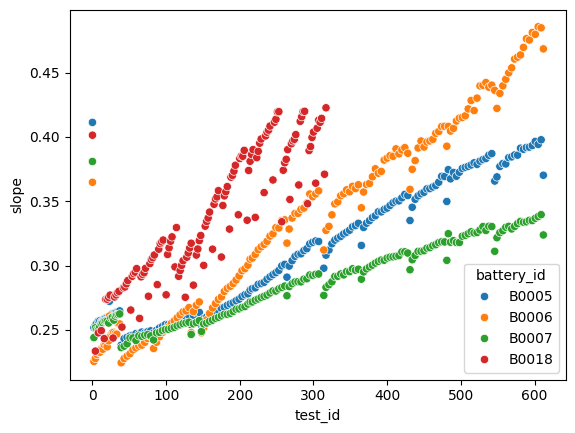

In [45]:
result_slopes_df = pd.DataFrame(results_slopes)
sns.scatterplot(data=result_slopes_df, x="test_id", y="slope", hue="battery_id")

<Axes: title={'center': 'B0018'}, xlabel='capacity_Ah', ylabel='Voltage_measured'>

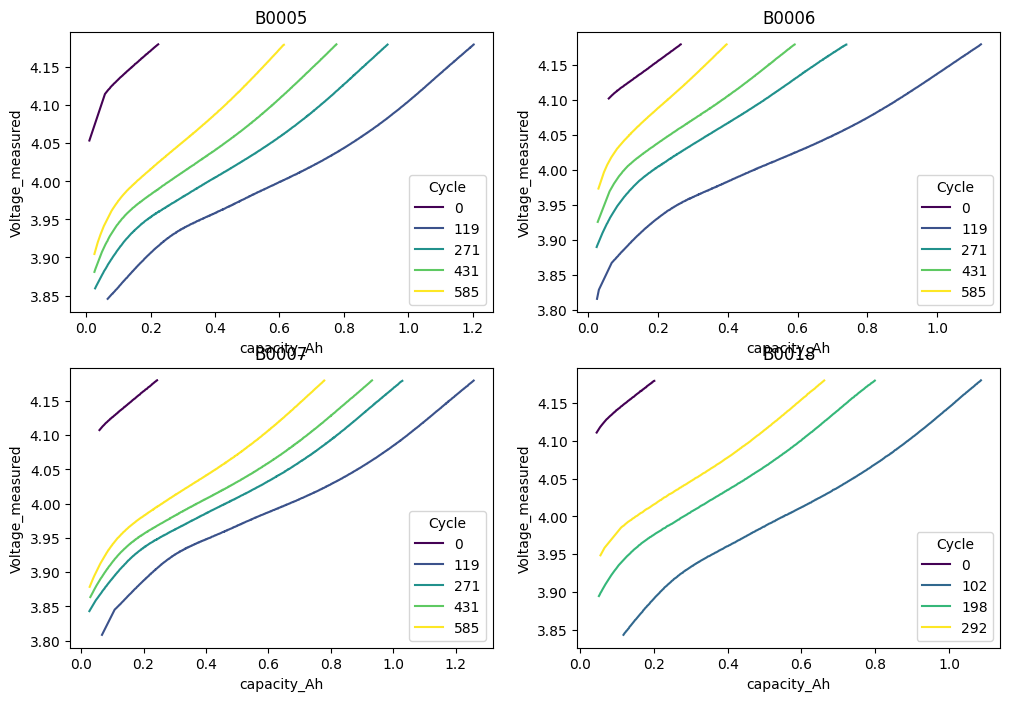

In [46]:
visualization_2by2(slopeV, x="capacity_Ah", y="Voltage_measured")

In [47]:
# HI curves
slopeV["capacity_Ah_smoothed"]=gaussian_filter1d(slopeV["capacity_Ah"], sigma=10)
slopeV["Voltage_measured_smoothed"]=gaussian_filter1d(slopeV["Voltage_measured"],sigma=10)
slopeV["dQ"] = slopeV["capacity_Ah_smoothed"].diff()
slopeV["dQ_smoothed"] = gaussian_filter1d(slopeV["dQ"], sigma=10)
slopeV["dV"] = slopeV["Voltage_measured_smoothed"].diff()
slopeV["dV_smoothed"] = gaussian_filter1d(slopeV["dV"], sigma=10)
slopeV["dQdV_smoothed"] = slopeV["dQ_smoothed"]/slopeV["dV_smoothed"]


(-2.0, 10.0)

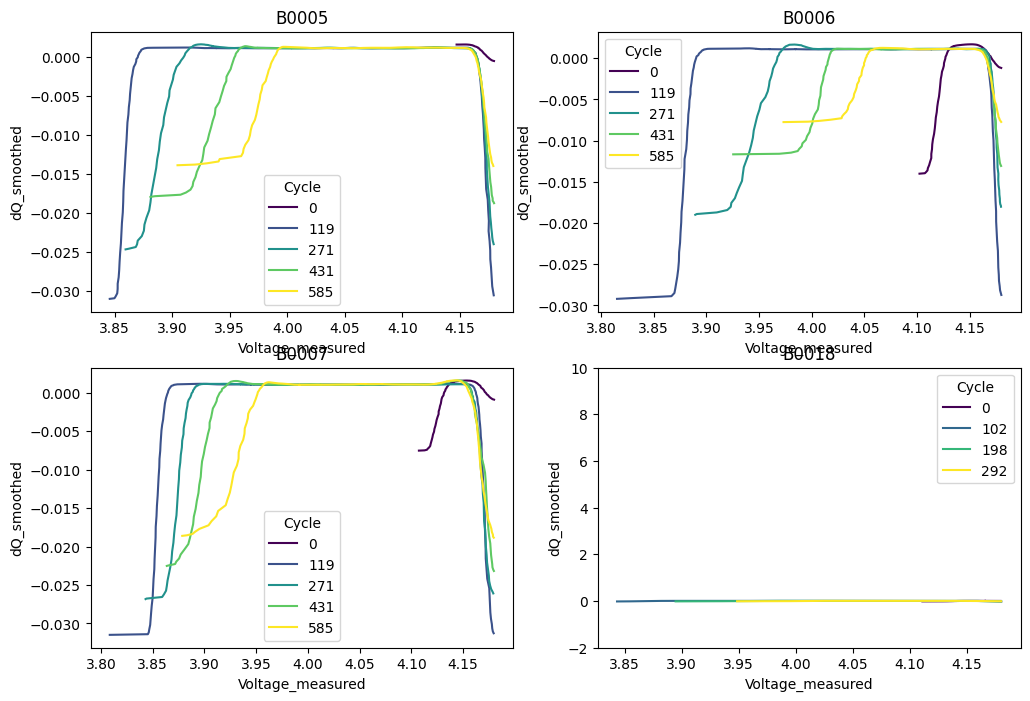

In [48]:
visualization_2by2(slopeV, x="Voltage_measured", y="dQ_smoothed")
plt.ylim(-2,10)

## Features extracted from charging: 
1. Time it takes to reach 4.2 V
2. Time of max temperature
3. Exponential coefficient of the CV phase.

# Discharge

In [210]:
B1_discharge = B1_charge_discharge.loc[B1_charge_discharge["type"]=="discharge"]
B1_discharge.reset_index(drop=True).head(5)



,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,new_time,Capacity,Current_load,Voltage_load,dt_exp,real_time,norm_time,capacity_Ah
0,4.191492,-0.004902,24.330034,NaN,NaN,0.000,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,0.000,8243.672001,8243.672001,0.001706,0.000000
1,4.190749,-0.001478,24.325993,NaN,NaN,16.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,4.206,0.000000,8260.453001,0.001710,-0.000007
2,3.974871,-2.012528,24.389085,NaN,NaN,35.703,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.062,0.000000,8279.375001,0.001714,-0.010585
3,3.951717,-2.013979,24.544752,NaN,NaN,53.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.030,0.000000,8297.453001,0.001717,-0.020698
4,3.934352,-2.011144,24.731385,NaN,NaN,71.922,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.011,0.000000,8315.594001,0.001721,-0.030833


In [214]:
iCap_idx_D = B1_discharge.loc[B1_discharge["test_id"]==1].groupby("battery_id")["capacity_Ah"].idxmin()
iCap_B0018_D= B1_discharge.loc[((B1_discharge["battery_id"]=="B0018")&(B1_discharge["test_id"]==2))].groupby("battery_id")["capacity_Ah"].idxmin()
iCap_idx = pd.concat([iCap_idx_D,iCap_B0018_D])

#Locate the capacity value at each index
iCap_D = (B1_discharge.loc[iCap_idx, ["battery_id", "capacity_Ah"]].set_index("battery_id")["capacity_Ah"])

#Use value to calculate the SoH per cycle
B1_discharge["SoH_discharge"] = B1_discharge["capacity_Ah"]/B1_discharge["battery_id"].map(iCap_D)*100
iCap_D

battery_id
B0005   -1.861941
B0006   -2.051974
B0007   -1.918651
B0018   -1.868495
Name: capacity_Ah, dtype: float64

Text(0, 0.5, 'Voltage / V')

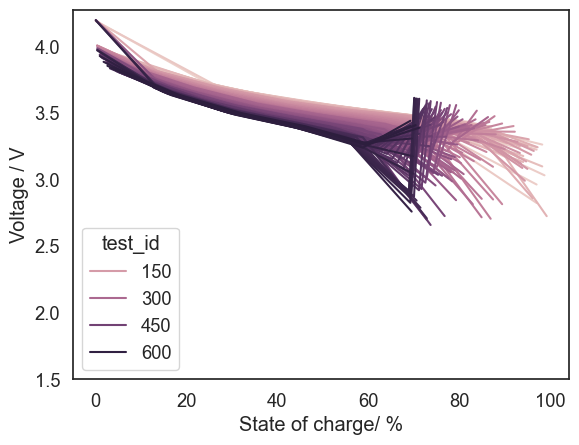

In [228]:
dfd = B1_discharge[["Voltage_measured","Current_measured","Temperature_measured","Time","battery_id","test_id","SoH_discharge"]].loc[(B1_discharge["battery_id"]=="B0005")].iloc[::50]
sns.set_theme(font_scale=1.2, style="white")
sns.lineplot(data=dfd, x="SoH_discharge", y="Voltage_measured", hue="test_id")
plt.ylim(1.5,)
plt.xlabel("State of charge/ %")
plt.ylabel("Voltage / V")

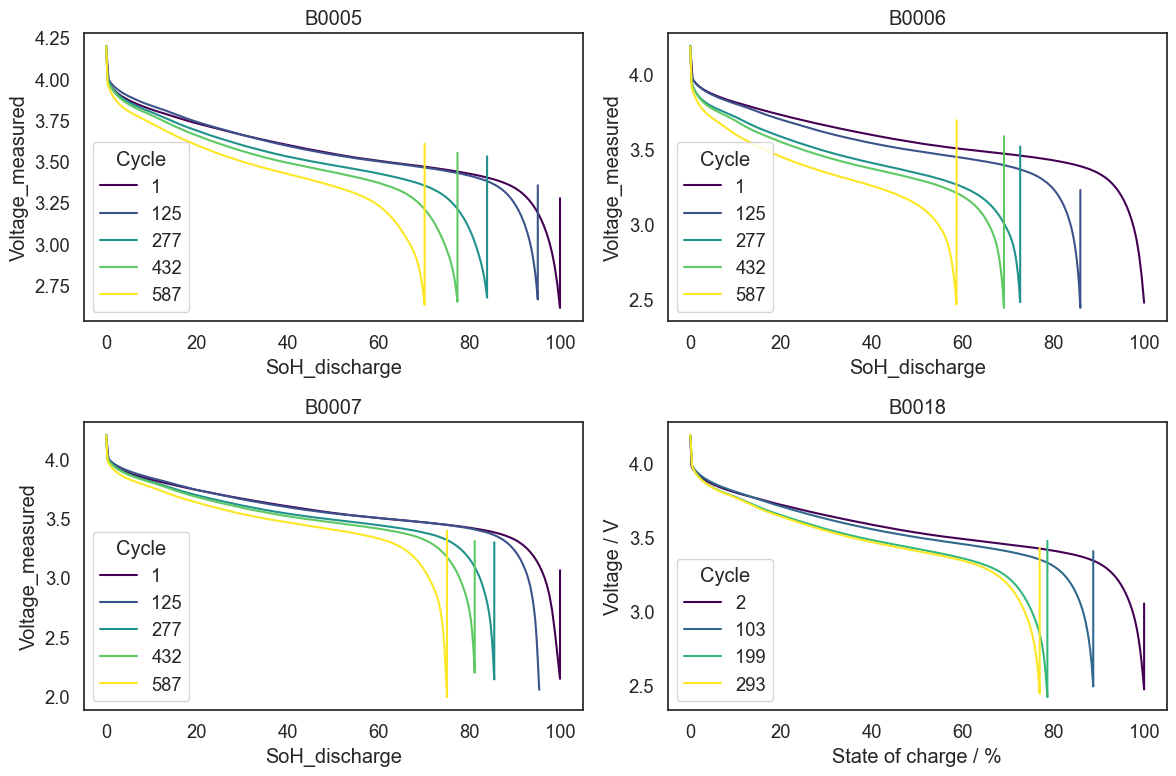

In [219]:
from utils import visualization_2by2
visualization_2by2(B1_discharge, "SoH_discharge", "Voltage_measured")
plt.xlabel("State of charge / %")
plt.ylabel("Voltage / V")
plt.tight_layout()
plt.show()

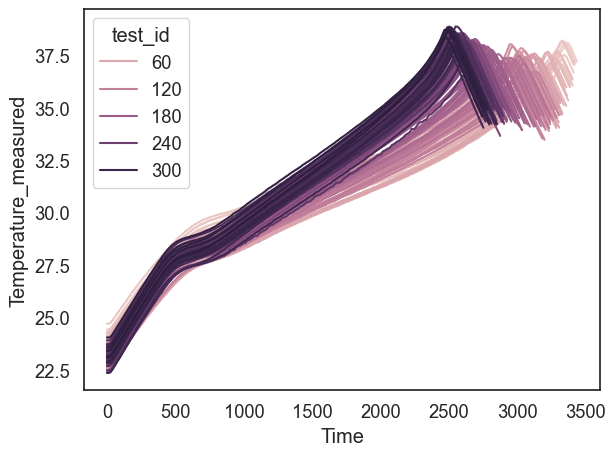

In [172]:
bat18 =B1_discharge.loc[B1_discharge["battery_id"]=="B0018"]
sns.lineplot(bat18, x="Time", y="Temperature_measured", hue="test_id")
plt.tight_layout()
plt.show()

In [173]:
B1_discharge = B1_discharge.copy()
results=[]
grouped = B1_discharge.groupby(["battery_id", "test_id"])
for (battery, cycle), cycle_df in grouped:
    cycle_df = cycle_df.sort_values("Time")

    idx_Tmax = cycle_df["Temperature_measured"].idxmax()
    Tmax = cycle_df.loc[idx_Tmax, "Temperature_measured"]
    t_Tmax = cycle_df.loc[idx_Tmax, "Time"]

    truncated_cycle_df = cycle_df.truncate(after = idx_Tmax)
    x=truncated_cycle_df["Temperature_measured"].values
    y=truncated_cycle_df["Time"].values
    res = linregress(x, y)
    slope= res.slope
    intercept = res.intercept
    
    results.append({
        "battery_id": battery,
        "test_id": cycle,
        "t_Tmax": t_Tmax,
        "Tmax" : Tmax,
        "slope": slope,
        "intercept": intercept
        })

results_df = pd.DataFrame(results)

In [174]:
results_df

,battery_id,test_id,t_Tmax,Tmax,slope,intercept
0,B0005,1,3366.781,38.982181,279.632430,-7354.211598
1,B0005,3,3348.735,39.033398,283.720153,-7538.845491
2,B0005,5,3329.281,38.818797,285.826912,-7594.918508
3,B0005,7,3329.500,38.762305,286.459397,-7579.304076
4,B0005,9,3327.531,38.665393,285.958292,-7524.767948
...,...,...,...,...,...,...
631,B0018,308,2513.250,38.847490,191.985684,-4753.980609
632,B0018,310,2487.563,38.802834,195.286160,-4899.423976
633,B0018,313,2481.078,38.726991,188.157262,-4632.323163
634,B0018,316,2500.703,38.671920,189.976575,-4642.893390


<Axes: xlabel='test_id', ylabel='intercept'>

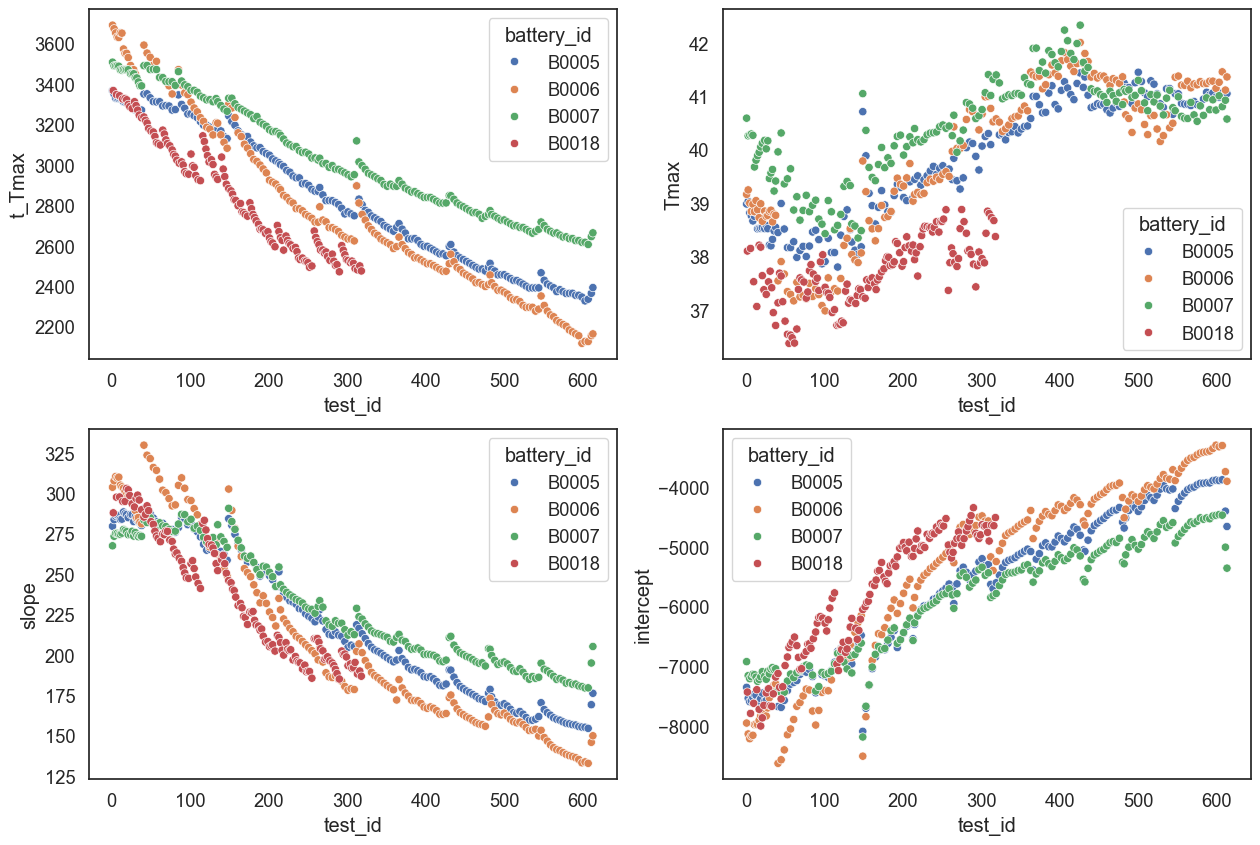

In [175]:
fig, ax = plt.subplots(2,2, figsize=(15,10))
sns.scatterplot(results_df, x="test_id", y="t_Tmax", hue = "battery_id", ax=ax[0,0])
sns.scatterplot(results_df, x="test_id", y="Tmax", hue = "battery_id",ax=ax[0,1])
sns.scatterplot(results_df, x="test_id", y="slope", hue = "battery_id",ax=ax[1,0])
sns.scatterplot(results_df, x="test_id", y="intercept", hue = "battery_id",ax=ax[1,1])

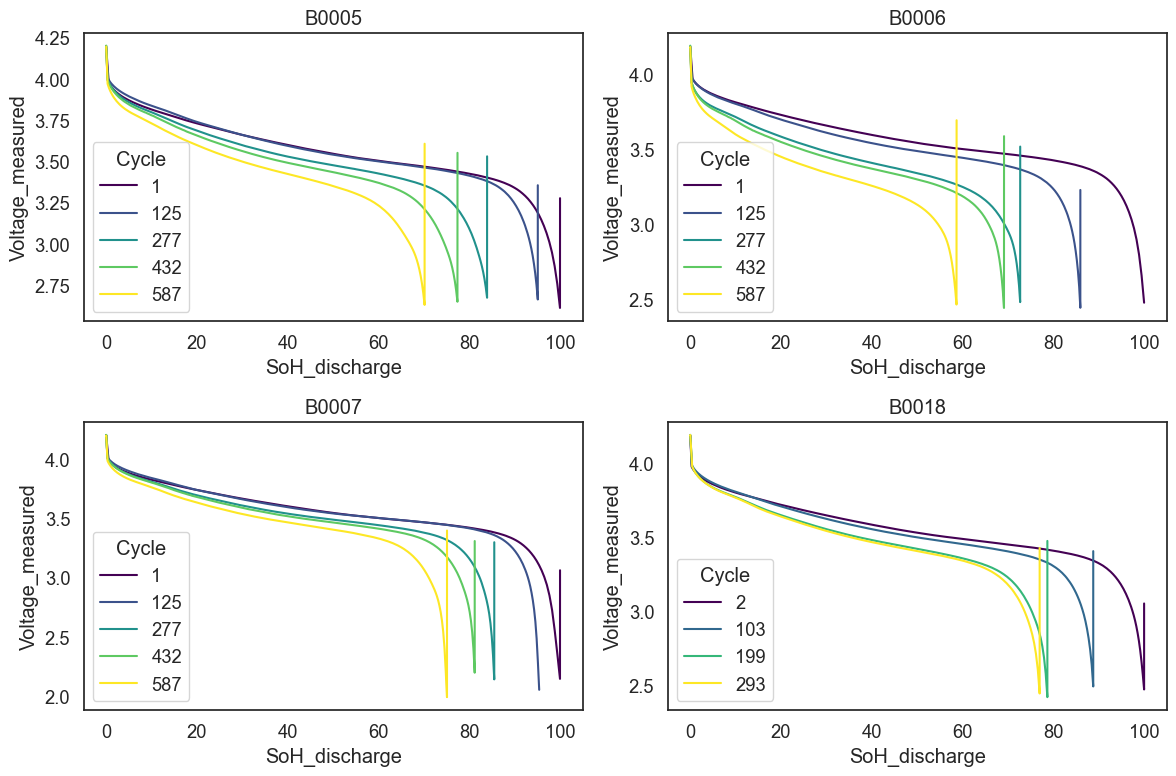

In [220]:
visualization_2by2(B1_discharge, "SoH_discharge", "Voltage_measured")
plt.tight_layout()
plt.show()

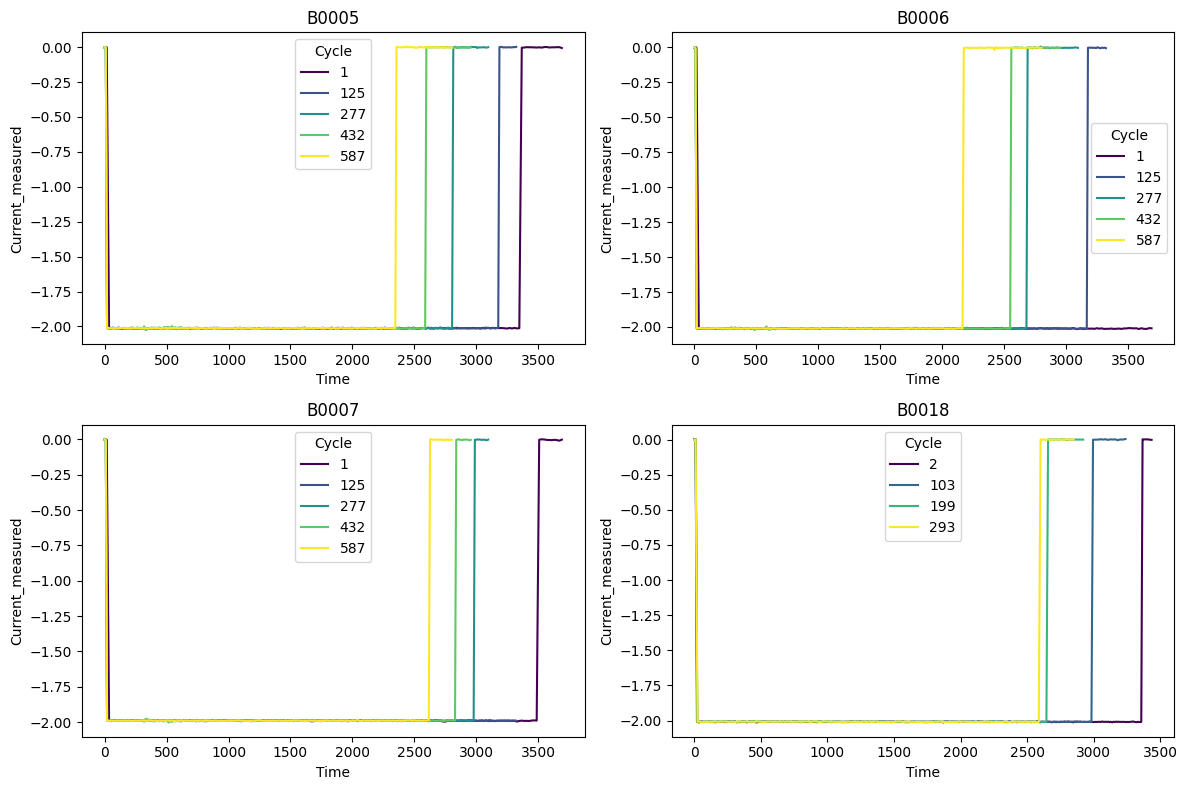

In [157]:
visualization_2by2(B1_discharge, "Time", "Current_measured")
plt.tight_layout()
plt.show()

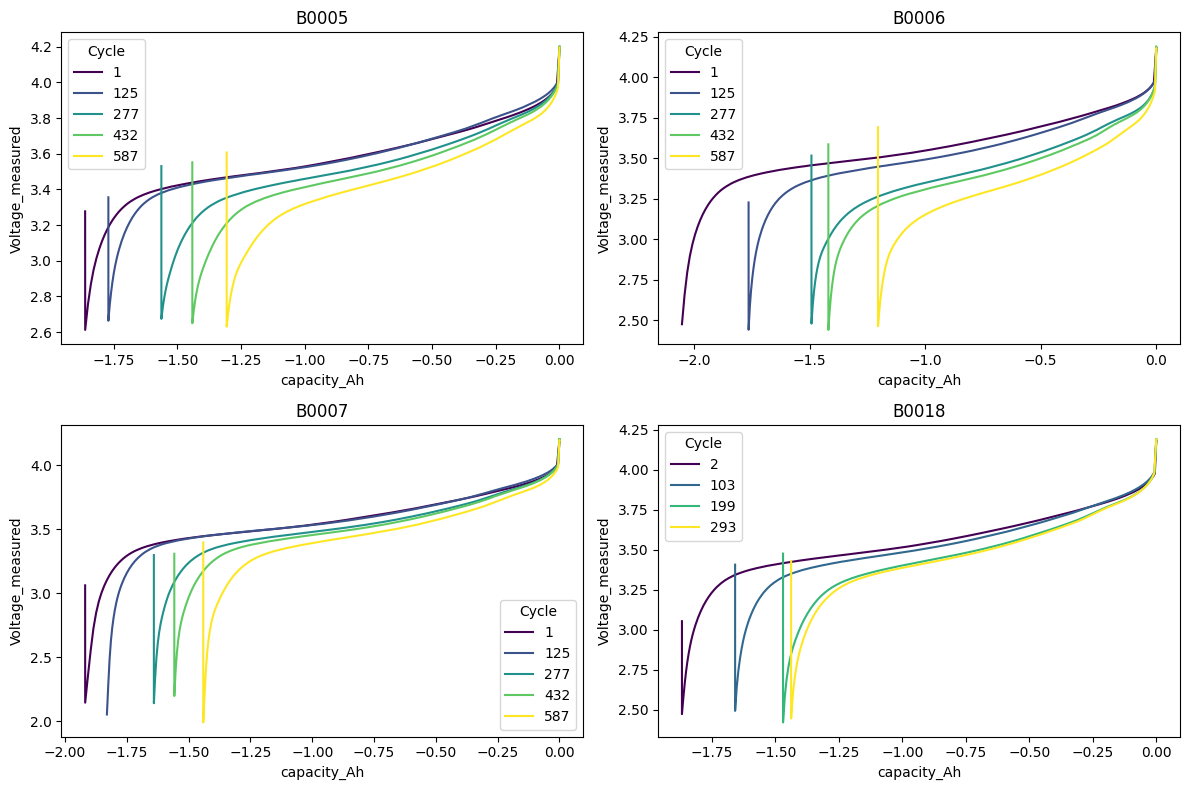

In [159]:
visualization_2by2(B1_discharge, "capacity_Ah", "Voltage_measured")
plt.tight_layout()
plt.show()

In [ ]:
##Measure time after truncation of voltage to remove spike after current goes to 0
B1_discharge = B1_discharge.copy()
results_Vdischarge=[]
grouped = B1_discharge.groupby(["battery_id", "test_id"])
for (battery, cycle), cycle_df in grouped:
    cycle_df = cycle_df.sort_values("Time")


    idx_Vmin = cycle_df["Voltage_measured"].idxmin()
    truncated_cycle_df = cycle_df.truncate(after = idx_Vmin)
    truncated_cycle_df = truncated_cycle_df.loc[truncated_cycle_df["Voltage_measured"]>2.8]
    t_duration = truncated_cycle_df["Time"].iloc[-1] - truncated_cycle_df["Time"].iloc[0]
    
    #when SoH is 10%
    mask_SoH10 = np.isclose(truncated_cycle_df["SoH_discharge"],10,atol=0.5)
    idx_SoH10 = truncated_cycle_df.loc[mask_SoH10].first_valid_index()
    V_SoH10 = truncated_cycle_df.loc[idx_SoH10, "Voltage_measured"]
    
    #when SoH is 50%
    mask_SoH50 = np.isclose(truncated_cycle_df["SoH_discharge"],50,atol=0.5)
    idx_SoH50 = truncated_cycle_df.loc[mask_SoH50].first_valid_index()
    V_SoH50 = truncated_cycle_df.loc[idx_SoH50, "Voltage_measured"]
    
    #Area under the curve Voltage-time
    X = truncated_cycle_df["Time"].values
    Y = truncated_cycle_df["Voltage_measured"].values
    A = np.trapezoid(Y,X)

    
    results_Vdischarge.append({
        "battery_id": battery,
        "test_id": cycle,
        "t_discharge": t_duration,
        "V_SoH10" : V_SoH10,
        "V_SoH50":V_SoH50,
        "voltage_profile_area" : A,

        })
    
results_Vdischarge_df = pd.DataFrame(results_Vdischarge)


In [259]:
B1_discharge.columns

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time', 'type', 'test_id',
       'battery_id', 'start_time', 'Capacity', 'Current_load', 'Voltage_load',
       'real_time', 'norm_time', 'capacity_Ah', 'SoH'],
      dtype='str')

# Conclusions: 

- Time dependent parameters are the most relevant for the analysis of the degradation patterns. 
- All features resulted in functions that can be found in the utils files

